In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Extraer información de la base de datos

In [95]:
# Cargar primera base de datos sin encabezados
raw_data = pd.read_excel(
    'datos/DATOS HISTÓRICOS 2023_2024_TODAS ESTACIONES_ITESM.xlsx',
    header=None
)

# Tomar las primeras 3 filas como cabecera y forzar a string
header = raw_data.iloc[0:3].astype(str)

# Rellenar NaN con vacío y concatenar todas las filas de cada columna
new_columns = (
    header.fillna("")
    .apply(lambda x: " ".join(x), axis=0)        # siempre une las 3 filas
    .str.replace(r"\s+", " ", regex=True)        # limpiar espacios múltiples
    .str.strip()                                 # quitar espacios extremos
)

# Asignar los nombres de columna
raw_data.columns = new_columns

# Quitar las filas de metadatos
raw_data = raw_data.iloc[3:].reset_index(drop=True)

# --- Debug extra: mostrar problemas potenciales ---
print("Total columnas:", len(raw_data.columns))
print("Duplicados:", raw_data.columns[raw_data.columns.duplicated()].unique())


raw_data.shape


Total columnas: 240
Duplicados: Index(['nan nan nan'], dtype='object')


(13870, 240)

In [98]:
# Cargar segunda base de datos
ex_rest_24 = pd.read_excel('datos/DATOS HISTÓRICOS 2024_TODAS ESTACIONES.xlsx', sheet_name=None)
rest_24 = pd.concat(ex_rest_24.values(), axis=1)
rest_24.shape

(8784, 240)

# Limpieza, Tipo de Datos, Valores Faltantes

In [99]:
# Eliminar columnas vacias o redundantes
rest_24.drop(columns='Fecha y hora', inplace=True)

# Quitar de raw_data las columnas llamadas 'nan nan nan'
raw_data.drop(columns='nan nan nan', inplace=True)

In [102]:
raw_data.shape, rest_24.shape

((13870, 226), (8784, 226))

In [103]:
# Establecer nans y cambiar nombre de la primera columna
raw_data.replace("", np.nan, inplace=True)
raw_data.rename(columns={'nan nan date': 'Date'}, inplace=True)

In [107]:
# Resetear index
raw_data = raw_data.reset_index(drop=True)

In [110]:
# Hacer datetime columna Date
rest_24['Date'] = pd.to_datetime(rest_24['Date'])
raw_data["Date"] = pd.to_datetime(raw_data["Date"])

In [113]:
# Hacer Columnas Numéricas
for col in raw_data.columns:
    if col != "Date":
        raw_data[col] = pd.to_numeric(raw_data[col], errors="coerce")

In [119]:
# Print column name 1 by 1
for col in range(len(rest_24.columns)):
    print(raw_data.columns[col])
    print(rest_24.columns[col])
    print("\n")

Date
Date


SURESTE CO ppm
CO (ppm)


SURESTE NO ppb
NO (ppb)


SURESTE NO2 ppb
NO2 (ppb)


SURESTE NOX ppb
NOX (ppb)


SURESTE O3 ppb
O3 (ppb)


SURESTE PM10 ug/m3
PM10 (ug/m3)


SURESTE PM2.5 ug/m3
PM2.5 (ug/m3)


SURESTE PRS mmhg
PRS (mmHg)


SURESTE RAINF mm/hr
RAINF (mm/h)


SURESTE RH %
RH (%)


SURESTE SO2 ppb
SO2 (ppb)


SURESTE SR KW/m2
SR (kW/m2)


SURESTE TOUT degC
TOUT (ºC)


SURESTE WSR KMPH
WSR (km/h)


SURESTE WDV DEG
WDR (azimutal)


NORESTE CO ppm
CO (ppm)


NORESTE NO ppb
NO (ppb)


NORESTE NO2 ppb
NO2 (ppb)


NORESTE NOX ppb
NOX (ppb)


NORESTE O3 ppb
O3 (ppb)


NORESTE PM10 ug/m3
PM10 (ug/m3)


NORESTE PM2.5 ug/m3
PM2.5 (ug/m3)


NORESTE PRS mmhg
PRS (mmHg)


NORESTE RAINF mm/hr
RAINF (mm/h)


NORESTE RH %
RH (%)


NORESTE SO2 ppb
SO2 (ppb)


NORESTE SR KW/m2
SR (kW/m2)


NORESTE TOUT degC
TOUT (ºC)


NORESTE WSR KMPH
WSR (km/h)


NORESTE WDV DEG
WDR (azimutal)


CENTRO CO ppm
CO (ppm)


CENTRO NO ppb
NO (ppb)


CENTRO NO2 ppb
NO2 (ppb)


CENTRO NOX ppb
NOX (ppb)




In [120]:
# Resetear el indice como la fecha
raw_data.set_index("Date", inplace=True)
rest_24.set_index('Date', inplace=True)

In [121]:
raw_data.shape, rest_24.shape

((13870, 225), (8784, 225))

In [122]:
# Combinar ambos dataframes en uno
nombre_columnas = raw_data.columns
rest_24_1 = rest_24.loc['2024-08-01 01:00:00':]
rest_24_1.columns = nombre_columnas
raw_data = pd.concat([raw_data, rest_24_1], axis=0)

# Revisar valores nulos
print(raw_data.shape)
raw_data.isna().sum()


(17541, 225)


SURESTE CO ppm          1005
SURESTE NO ppb           407
SURESTE NO2 ppb          172
SURESTE NOX ppb          173
SURESTE O3 ppb           486
                        ... 
NOROESTE 3 SO2 ppb      4476
NOROESTE 3 SR KW/m2      764
NOROESTE 3 TOUT degC     246
NOROESTE 3 WSR KMPH     2105
NOROESTE 3 WDR DEG       320
Length: 225, dtype: int64

In [123]:
raw_data.to_csv('datos/raw1.csv', index=True)
rest_24.to_csv('datos/rest_24.csv', index=True)


In [124]:
# Combinar ambos dataframes en uno
nombre_columnas = raw_data.columns
rest_24_1 = rest_24.loc['2024-08-01 01:00:00':]
rest_24_1.columns = nombre_columnas
raw_data = pd.concat([raw_data, rest_24_1], axis=0)

# Revisar valores nulos
print(raw_data.shape)
raw_data.isna().sum()

(21212, 225)


SURESTE CO ppm          1825
SURESTE NO ppb           448
SURESTE NO2 ppb          191
SURESTE NOX ppb          192
SURESTE O3 ppb           566
                        ... 
NOROESTE 3 SO2 ppb      7588
NOROESTE 3 SR KW/m2     1386
NOROESTE 3 TOUT degC     375
NOROESTE 3 WSR KMPH     2243
NOROESTE 3 WDR DEG       424
Length: 225, dtype: int64

In [127]:
# Primero utilizamos interpolación de datos faltantes en espacios más pequeños, usando una interpolación lineal para no más de 3 datos faltantes consecutivos
data_interpolate = (
    raw_data
    .interpolate(method="time", limit=3, limit_direction="both", limit_area="inside")
)

data_interpolate.isna().sum()

SURESTE CO ppm          1501
SURESTE NO ppb            26
SURESTE NO2 ppb           26
SURESTE NOX ppb           26
SURESTE O3 ppb            73
                        ... 
NOROESTE 3 SO2 ppb      7128
NOROESTE 3 SR KW/m2      810
NOROESTE 3 TOUT degC      54
NOROESTE 3 WSR KMPH     1743
NOROESTE 3 WDR DEG        87
Length: 225, dtype: int64

In [129]:
# Para rellenar espacios grandes de missing values utilizando un KNNIMPUTE 
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(data_interpolate), columns=data_interpolate.columns, index=data_interpolate.index)
df_imputed.isna().sum()

SURESTE CO ppm          0
SURESTE NO ppb          0
SURESTE NO2 ppb         0
SURESTE NOX ppb         0
SURESTE O3 ppb          0
                       ..
NOROESTE 3 SO2 ppb      0
NOROESTE 3 SR KW/m2     0
NOROESTE 3 TOUT degC    0
NOROESTE 3 WSR KMPH     0
NOROESTE 3 WDR DEG      0
Length: 225, dtype: int64

In [130]:
df_imputed.columns[7]

'SURESTE PRS mmhg'

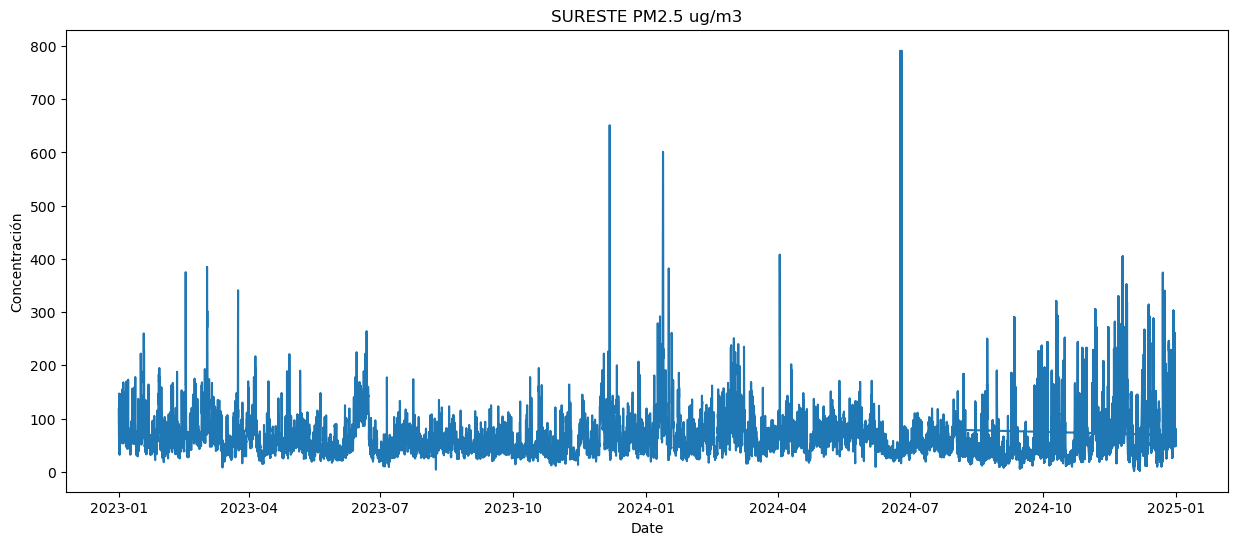

In [137]:
# Ejemplo de los datos en una variable 
plt.figure(figsize=(15,6))
plt.plot(df_imputed['CENTRO PM10 ug/m3'])
plt.title('SURESTE PM2.5 ug/m3')
plt.ylabel('Concentración')
plt.xlabel('Date')
plt.show()

In [138]:
df_imputed.to_csv('datos/datos_limpios.csv', index=True)